# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (26 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.6 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl (178.7 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl (1.8 MB)
Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp3

In [2]:
import torch
import numpy as np

In [4]:
import data

model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), #Input (x, y)
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1) #Output (z), 50 decides number of layers
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [5]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.6675853729248047
Iteration 100, Loss: 1.0405476093292236
Iteration 200, Loss: 1.0115987062454224
Iteration 300, Loss: 0.9716045260429382
Iteration 400, Loss: 0.9140779972076416
Iteration 500, Loss: 0.8374924659729004
Iteration 600, Loss: 0.7468542456626892
Iteration 700, Loss: 0.6532914042472839
Iteration 800, Loss: 0.5696567296981812
Iteration 900, Loss: 0.5025835633277893


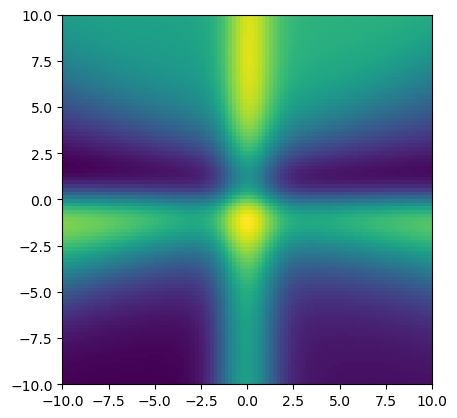

In [7]:
#initial results
import matplotlib.pyplot as plt
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid(new_x, new_x), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [ ]:
#Artifical intelligence is a broad field, focused on the ability of machines to imitate human behavior
#machine learning is a form of AI, where algorithms are used to learn from data
#deep learning is a form of ML, where neural networks are used to find complex patterns in data

What is a neural network?

In [ ]:
#a machine learning model that makes decisions in a similar way to the human brain

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [1]:
#the inputs (x, y)

What does the activation function do?

In [ ]:
# It takes any input and maps it to a value between 0 and 1, which can be interpreted as a probability.

What is a loss function? Why do we need one?

In [ ]:
#Loss function - how wrong is our model?
#shows us accuracy, letting us know how much we need to improve the model

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [ ]:
#you have so zero out the gradient before the next backward pass because gradients are accumulated by default

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [6]:
#original: 
"""
 torch.nn.Linear(2, 50), #Input (x, y)
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1) """
#changes to:
 """torch.nn.Linear(2, 30), #Input (x, y)
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1) """

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [13]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), #Input (x, y)
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [14]:
import data
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.0750113725662231
Iteration 100, Loss: 1.0293223857879639
Iteration 200, Loss: 0.9842973351478577
Iteration 300, Loss: 0.9035719037055969
Iteration 400, Loss: 0.8086727261543274
Iteration 500, Loss: 0.7273285984992981
Iteration 600, Loss: 0.6652675867080688
Iteration 700, Loss: 0.621722936630249
Iteration 800, Loss: 0.5924562215805054
Iteration 900, Loss: 0.5719264149665833


In [ ]:
#final loss function value is greater for modification than original

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [15]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), #Input (x, y)
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
import data
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 2.394611358642578
Iteration 100, Loss: 0.9902781844139099
Iteration 200, Loss: 0.8946506381034851
Iteration 300, Loss: 0.7731013298034668
Iteration 400, Loss: 0.6598913073539734
Iteration 500, Loss: 0.5720819234848022
Iteration 600, Loss: 0.5133095383644104
Iteration 700, Loss: 0.47668877243995667
Iteration 800, Loss: 0.44994133710861206
Iteration 900, Loss: 0.42474043369293213


In [ ]:
#final loss function value is smaller for modification than original

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [17]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), #Input (x, y)
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [18]:
import data
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.06476628780365
Iteration 100, Loss: 0.7572538256645203
Iteration 200, Loss: 0.5095933675765991
Iteration 300, Loss: 0.3641270101070404
Iteration 400, Loss: 0.2874869704246521
Iteration 500, Loss: 0.24429592490196228
Iteration 600, Loss: 0.21302831172943115
Iteration 700, Loss: 0.18842843174934387
Iteration 800, Loss: 0.16553853452205658
Iteration 900, Loss: 0.1467338651418686


In [ ]:
#final loss function value is smaller for modification than original
#achieves greatest accuracy out of all modifications

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [ ]:
#torch.nn.Tanh() achieves the highest accuracy in the same time, next best accuracy is torch.nn.Sigmoid(), torch.nn.ReLU had the lowest accuracy
#In terms of function: Sigmoid limits outputs to the range, ReLU outputs the input if positive, zero otherwise, and Tanh outputs values between -1 and 1. 

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [19]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), #Input (x, y)
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [20]:
import data
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.397922396659851
Iteration 100, Loss: 0.7061731219291687
Iteration 200, Loss: 0.3780898153781891
Iteration 300, Loss: 0.27047303318977356
Iteration 400, Loss: 0.1811763495206833
Iteration 500, Loss: 0.13636884093284607
Iteration 600, Loss: 0.11803142726421356
Iteration 700, Loss: 0.09965670853853226
Iteration 800, Loss: 0.08664412051439285
Iteration 900, Loss: 0.07949990034103394


In [ ]:
#With the modification, significantly higher accuracy was achieved than in the lecture example

Modify your model to have **two hidden layers** instead of one. Give that code here.

In [4]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), #Input (x, y)
    torch.nn.Sigmoid(),
    torch.nn.Tanh(),
    torch.nn.Linear(30, 1) 
)

#Loss function - how wrong is our model?
loss_fn = torch.nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [5]:
import data
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 ==0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 0.9813084602355957
Iteration 100, Loss: 0.37008869647979736
Iteration 200, Loss: 0.22990190982818604
Iteration 300, Loss: 0.14277634024620056
Iteration 400, Loss: 0.10812526196241379
Iteration 500, Loss: 0.08450397849082947
Iteration 600, Loss: 0.07014907151460648
Iteration 700, Loss: 0.06429676711559296
Iteration 800, Loss: 0.06166907399892807
Iteration 900, Loss: 0.060167524963617325


# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [ ]:
#PLEASE REFRENCE FILE LABELLED HW16Q3, There were issues loading the changes I made to the data so I had to move everything to a new notebook to get it to work

Define a new model and train it **poorly** in the cell below.

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [47]:
#I tried to use data from a UCI ML repo but there were too many issues with loading the data so I decided to create my own

In [3]:
#As with the previous section there were issues with my notebook loading the data so look at file with name HW16Q4 for answers

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!